# Inspect Corrected Wind Direction

Quick checks for the corrected EddyPro wind direction time series.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

In [9]:
FILE_CORRECTED = Path('data/SILVEX1_Silvia3/2m/eddypro_24Silvia32_full_output_2026-01-20T152106_adv_windcorr.csv')
FILE_RAW = Path(str(FILE_CORRECTED).replace('_windcorr.csv', '.csv'))

FILE_CORRECTED, FILE_RAW

(WindowsPath('data/SILVEX1_Silvia3/2m/eddypro_24Silvia32_full_output_2026-01-20T152106_adv_windcorr.csv'),
 WindowsPath('data/SILVEX1_Silvia3/2m/eddypro_24Silvia32_full_output_2026-01-20T152106_adv.csv'))

In [10]:
def read_eddypro_adv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)

    # EddyPro adv format: row 1 metadata, row 2 header, row 3 units
    df = pd.read_csv(path, header=1, skiprows=[2])
    df['timestamp'] = pd.to_datetime(
        df['date'].astype(str).str.strip() + ' ' + df['time'].astype(str).str.strip(),
        errors='coerce',
    )
    df['wind_dir'] = pd.to_numeric(df['wind_dir'], errors='coerce')
    return df

def wind_direction_mean(series: pd.Series) -> float:
    vals = pd.to_numeric(series, errors='coerce').dropna().to_numpy(dtype=float)
    if vals.size == 0:
        return np.nan

    rad = np.deg2rad(vals)
    sin_mean = np.sin(rad).mean()
    cos_mean = np.cos(rad).mean()
    if np.isclose(sin_mean, 0.0) and np.isclose(cos_mean, 0.0):
        return np.nan

    return float((np.degrees(np.arctan2(sin_mean, cos_mean)) + 360) % 360)

corr = read_eddypro_adv(FILE_CORRECTED).dropna(subset=['timestamp']).sort_values('timestamp')

raw = None
if FILE_RAW.exists():
    raw = read_eddypro_adv(FILE_RAW).dropna(subset=['timestamp']).sort_values('timestamp')

print(f'Corrected rows: {len(corr):,}')
print(f'Corrected time span: {corr["timestamp"].min()} -> {corr["timestamp"].max()}')
print(f'Corrected valid wind_dir: {corr["wind_dir"].notna().sum():,}')
print(f'Corrected wind_dir min/max: {corr["wind_dir"].min():.2f} / {corr["wind_dir"].max():.2f}')

if raw is not None:
    print(f'Raw rows: {len(raw):,}')
    print(f'Raw valid wind_dir: {raw["wind_dir"].notna().sum():,}')

corr[['timestamp', 'wind_dir']].head()

Corrected rows: 24,514
Corrected time span: 2024-08-20 10:05:00 -> 2024-09-06 10:38:00
Corrected valid wind_dir: 23,543
Corrected wind_dir min/max: 0.04 / 359.56
Raw rows: 24,514
Raw valid wind_dir: 23,543


,timestamp,wind_dir
0,2024-08-20 10:05:00,97.3032
1,2024-08-20 10:06:00,96.2357
2,2024-08-20 10:07:00,94.5231
3,2024-08-20 10:08:00,98.4739
4,2024-08-20 10:09:00,96.1885


Matched timestamps (native): 23,543
30-min bins: 807


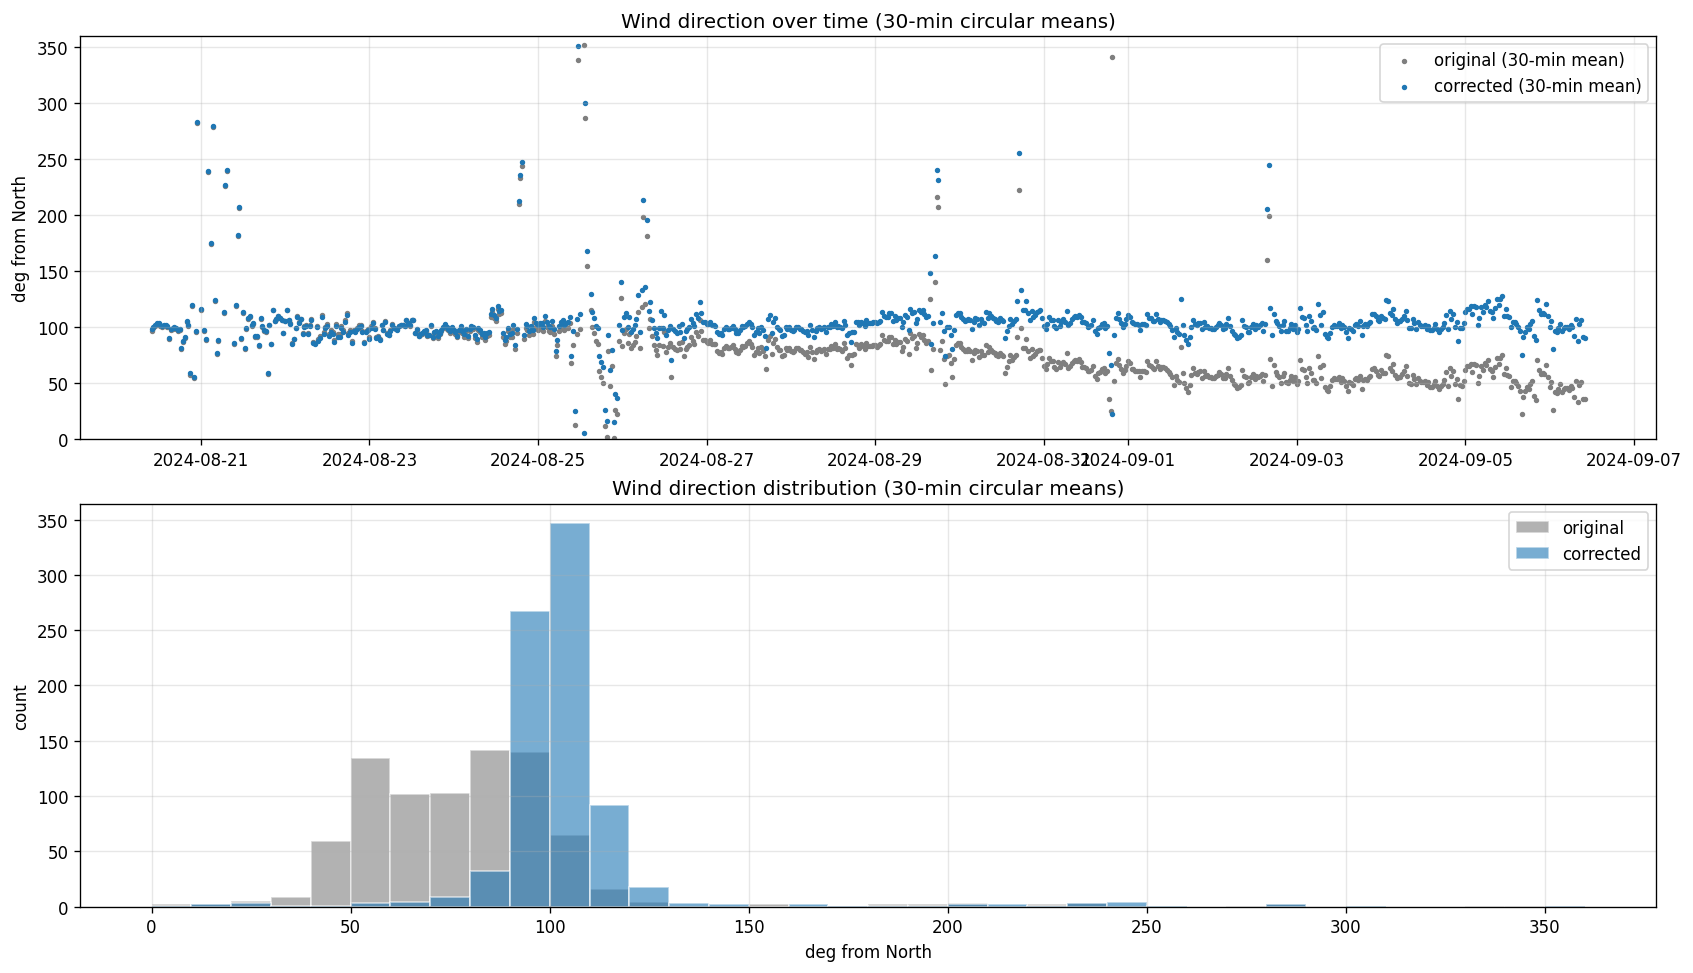

In [18]:
if raw is None:
    raise FileNotFoundError(f'Raw file not found: {FILE_RAW}')

comp = pd.merge(
    raw[['timestamp', 'wind_dir']].rename(columns={'wind_dir': 'wind_dir_raw'}),
    corr[['timestamp', 'wind_dir']].rename(columns={'wind_dir': 'wind_dir_corr'}),
    on='timestamp',
    how='inner',
).dropna().sort_values('timestamp')

comp_30 = (
    comp.set_index('timestamp')
        .resample('30min')
        .agg({
            'wind_dir_raw': wind_direction_mean,
            'wind_dir_corr': wind_direction_mean,
        })
        .dropna()
        .reset_index()
)

print(f'Matched timestamps (native): {len(comp):,}')
print(f'30-min bins: {len(comp_30):,}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].scatter(comp_30['timestamp'], comp_30['wind_dir_raw'], label='original (30-min mean)', s=5, color='tab:gray')
axes[0].scatter(comp_30['timestamp'], comp_30['wind_dir_corr'], label='corrected (30-min mean)', s=5, color='tab:blue')
axes[0].set_title('Wind direction over time (30-min circular means)')
axes[0].set_ylabel('deg from North')
axes[0].set_ylim(0, 360)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(comp_30['wind_dir_raw'], bins=np.arange(0, 361, 10), alpha=0.6, color='tab:gray', edgecolor='white', label='original')
axes[1].hist(comp_30['wind_dir_corr'], bins=np.arange(0, 361, 10), alpha=0.6, color='tab:blue', edgecolor='white', label='corrected')
axes[1].set_title('Wind direction distribution (30-min circular means)')
axes[1].set_xlabel('deg from North')
axes[1].set_ylabel('count')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()

30-min matched bins: 807
count    807.000000
mean      24.984865
std       19.382782
min       -1.984308
5%        -0.797573
50%       20.931077
95%       52.904373
max       55.000000
Name: delta_deg, dtype: float64


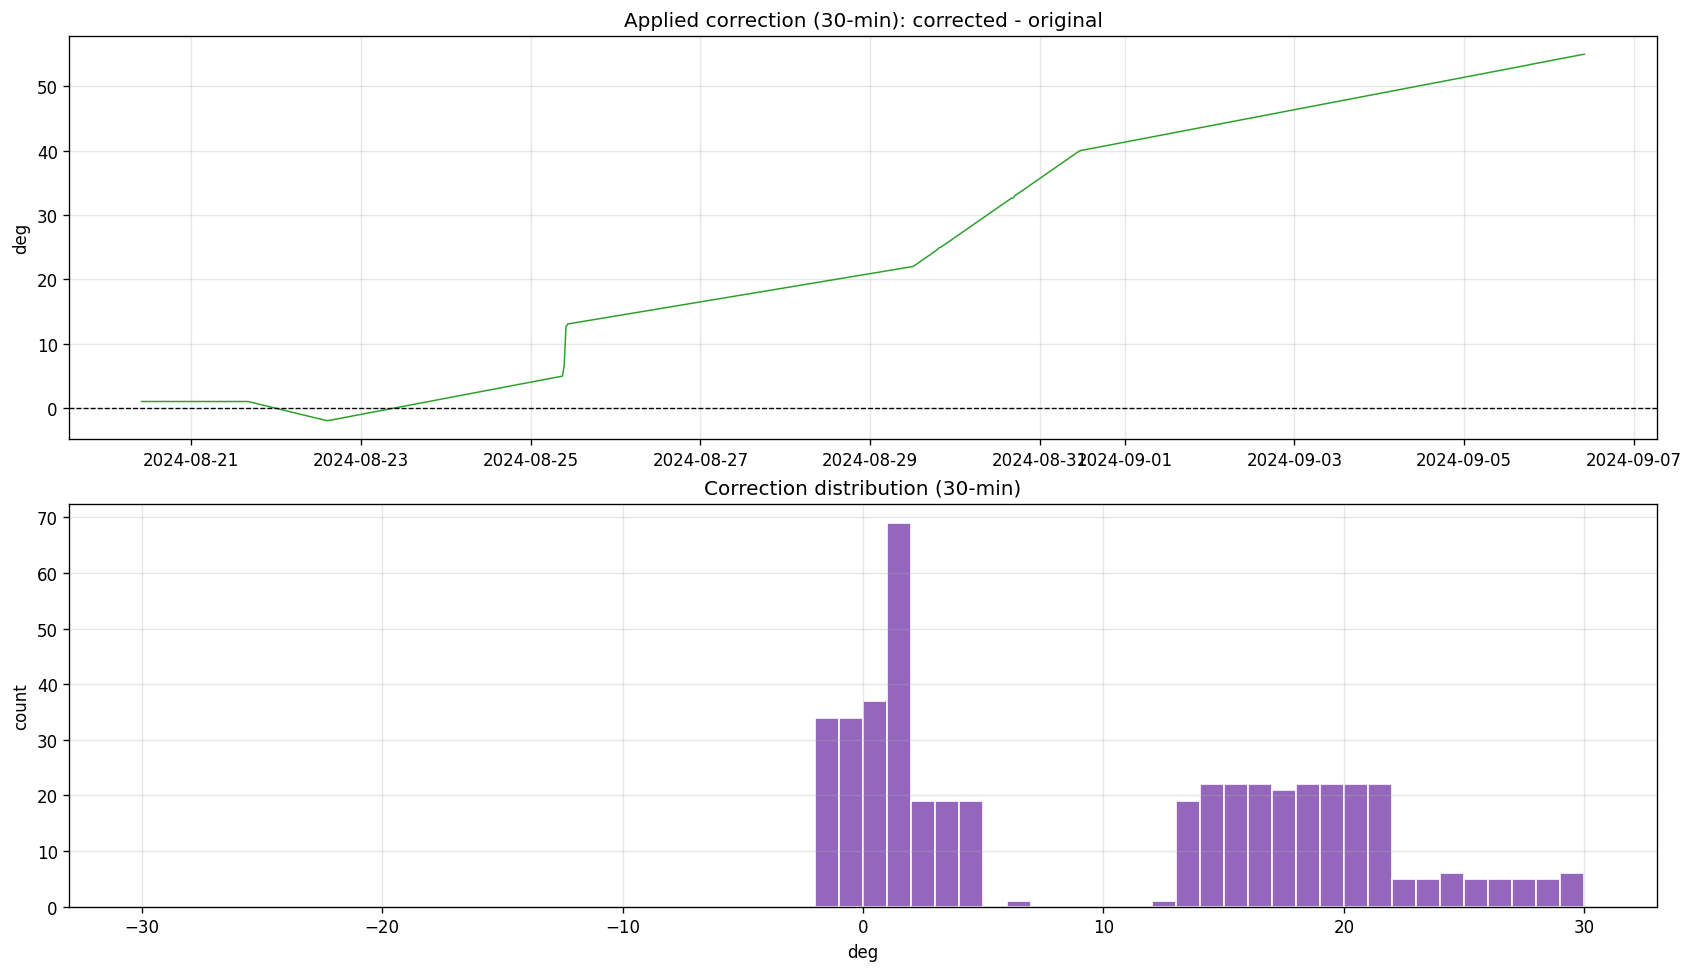

In [12]:
if 'comp_30' not in globals() or comp_30.empty:
    raise ValueError('Run the previous cell first to create 30-min merged wind-direction data.')

# Circular difference in [-180, 180) using 30-min means
comp_30['delta_deg'] = ((comp_30['wind_dir_corr'] - comp_30['wind_dir_raw'] + 180) % 360) - 180

print(f'30-min matched bins: {len(comp_30):,}')
print(comp_30['delta_deg'].describe(percentiles=[0.05, 0.5, 0.95]))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
axes[0].plot(comp_30['timestamp'], comp_30['delta_deg'], lw=0.9, color='tab:green')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Applied correction (30-min): corrected - original')
axes[0].set_ylabel('deg')
axes[0].grid(alpha=0.3)

axes[1].hist(comp_30['delta_deg'], bins=np.arange(-30, 31, 1), color='tab:purple', edgecolor='white')
axes[1].set_title('Correction distribution (30-min)')
axes[1].set_xlabel('deg')
axes[1].set_ylabel('count')
axes[1].grid(alpha=0.3)
plt.show()